In [1]:
# ── CELL 1 ── Mount Drive & install deps ────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

# Install mmcv from your saved wheel (fast path — skip if already done)
import os
WHEEL = '/content/drive/MyDrive/mmcv-2.1.0-cp312-cp312-linux_x86_64.whl'
if os.path.exists(WHEEL):
    os.system(f'pip install {WHEEL} -q')

os.system('pip install mmengine mmpose mmdet decord -q')

# Clone MMAction2 if not already present
if not os.path.isdir('/content/mmaction2'):
    os.system('git clone https://github.com/open-mmlab/mmaction2.git -q /content/mmaction2')
    os.system('pip install -e /content/mmaction2 -q')
    # Disable multimodal import that breaks with newer transformers
    os.system(
        "sed -i 's/from .multimodal import \\*/# from .multimodal import */' "
        "/content/mmaction2/mmaction/models/__init__.py"
    )
    # Patch torch.load for PyTorch 2.x weights_only default change
    os.system(
        "sed -i 's/checkpoint = torch.load(filename, map_location=map_location)/"
        "checkpoint = torch.load(filename, map_location=map_location, weights_only=False)/' "
        "/usr/local/lib/python3.12/dist-packages/mmengine/runner/checkpoint.py"
    )

print("Setup complete ✅")

Mounted at /content/drive
Setup complete ✅


In [ ]:
# ── CELL 2 ── Restart runtime after install ─────────────────────────────────
# Run this cell to restart the runtime so new packages are recognised.
import os
os.kill(os.getpid(), 9)

In [12]:
import copy

In [1]:
import os
os.makedirs('/content/drive/MyDrive/violence-detection/configs', exist_ok=True)

config_content = """
_base_ = '/content/mmaction2/configs/_base_/default_runtime.py'

model = dict(
    type='RecognizerGCN',
    backbone=dict(
        type='AAGCN',
        graph_cfg=dict(layout='coco', mode='spatial'),
        gcn_attention=False),
    cls_head=dict(type='GCNHead', num_classes=2, in_channels=256))

dataset_type = 'PoseDataset'
ann_file = '/content/drive/MyDrive/violence-detection/data/processed/pose/pkl/rwf_pose.pkl'

train_pipeline = [
    dict(type='PreNormalize2D'),
    dict(type='GenSkeFeat', dataset='coco', feats=['j']),
    dict(type='UniformSampleFrames', clip_len=100),
    dict(type='PoseDecode'),
    dict(type='FormatGCNInput', num_person=2),
    dict(type='PackActionInputs')
]
val_pipeline = [
    dict(type='PreNormalize2D'),
    dict(type='GenSkeFeat', dataset='coco', feats=['j']),
    dict(type='UniformSampleFrames', clip_len=100, num_clips=1, test_mode=True),
    dict(type='PoseDecode'),
    dict(type='FormatGCNInput', num_person=2),
    dict(type='PackActionInputs')
]
test_pipeline = [
    dict(type='PreNormalize2D'),
    dict(type='GenSkeFeat', dataset='coco', feats=['j']),
    dict(type='UniformSampleFrames', clip_len=100, num_clips=10, test_mode=True),
    dict(type='PoseDecode'),
    dict(type='FormatGCNInput', num_person=2),
    dict(type='PackActionInputs')
]

train_dataloader = dict(
    batch_size=16, num_workers=2, persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=True),
    dataset=dict(type='RepeatDataset', times=5, dataset=dict(
        type=dataset_type, ann_file=ann_file,
        pipeline=train_pipeline, split='train')))
val_dataloader = dict(
    batch_size=16, num_workers=2, persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(type=dataset_type, ann_file=ann_file,
        pipeline=val_pipeline, split='val', test_mode=True))
test_dataloader = dict(
    batch_size=1, num_workers=2, persistent_workers=True,
    sampler=dict(type='DefaultSampler', shuffle=False),
    dataset=dict(type=dataset_type, ann_file=ann_file,
        pipeline=test_pipeline, split='val', test_mode=True))

val_evaluator = [dict(type='AccMetric')]
test_evaluator = val_evaluator

train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=16, val_begin=1, val_interval=1)
val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

param_scheduler = [dict(type='CosineAnnealingLR', eta_min=0, T_max=16,
    by_epoch=True, convert_to_iter_based=True)]
optim_wrapper = dict(optimizer=dict(type='SGD', lr=0.1, momentum=0.9,
    weight_decay=0.0005, nesterov=True))

default_hooks = dict(checkpoint=dict(interval=1), logger=dict(interval=50))
auto_scale_lr = dict(enable=False, base_batch_size=128)
"""

with open('/content/drive/MyDrive/violence-detection/configs/2s-agcn_rwf2000_joint.py', 'w') as f:
    f.write(config_content)
print("✅ Joint config saved")

✅ Joint config saved


In [2]:
config_content = config_content.replace("feats=['j']", "feats=['b']")

with open('/content/drive/MyDrive/violence-detection/configs/2s-agcn_rwf2000_bone.py', 'w') as f:
    f.write(config_content)
print("✅ Bone config saved")

✅ Bone config saved


In [3]:
# ── CELL 3 ── Imports & config ───────────────────────────────────────────────
import sys, os, warnings
import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.models.video import r3d_18
from decord import VideoReader, cpu

warnings.filterwarnings("ignore")
sys.path.insert(0, '/content/mmaction2')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ── Paths — update these to match your Drive layout ──────────────────────────
BASE  = '/content/drive/MyDrive/violence-detection'

RGB_CKPT   = f'{BASE}/checkpoints/rgb_v2/best_model.pth'
JOINT_CKPT = f'{BASE}/checkpoints/pose/2s-agcn-joint/best_acc_top1_epoch_8.pth'
BONE_CKPT  = f'{BASE}/checkpoints/pose/2s-agcn-bone/best_acc_top1_epoch_13.pth'

JOINT_CFG = '/content/drive/MyDrive/violence-detection/configs/2s-agcn_rwf2000_joint.py'
BONE_CFG  = '/content/drive/MyDrive/violence-detection/configs/2s-agcn_rwf2000_bone.py'

# Fusion weights from grid search
W_RGB, W_JOINT, W_BONE = 0.45, 0.25, 0.30
CLASS_NAMES = ["NonFight", "Fight"]

Device: cuda


In [4]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.7 MB/s eta 0:00:00


In [5]:
# ── CELL 4 ── Helper functions ───────────────────────────────────────────────

# ── RGB ──────────────────────────────────────────────────────────────────────

def load_rgb_model(ckpt_path):
    model = r3d_18(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, 2)
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    state_dict = state.get("model_state_dict", state.get("state_dict", state))
    model.load_state_dict(state_dict)
    model.to(device).eval()
    print(f"  ✓ R3D-18 loaded from {os.path.basename(ckpt_path)}")
    return model


def get_rgb_probs(model, video_path, num_frames=16, size=112):
    vr  = VideoReader(video_path, ctx=cpu(0))
    idx = np.linspace(0, len(vr) - 1, num_frames, dtype=int)
    frames = vr.get_batch(idx).asnumpy()

    tf = T.Compose([
        T.ToPILImage(),
        T.Resize((size, size)),
        T.ToTensor(),
        T.Normalize(mean=[0.43216, 0.394666, 0.37645],
                    std =[0.22803,  0.22145,  0.216989]),
    ])
    clip = torch.stack([tf(f) for f in frames]).permute(1,0,2,3).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(clip)
    return F.softmax(logits, dim=1).cpu().numpy()[0]


# ── Skeleton extraction ───────────────────────────────────────────────────────

# ── CELL: Install YOLO (if not already installed) ────────────────────────────
# !pip install ultralytics -q

from ultralytics import YOLO
import cv2
import numpy as np

YOLO_MODEL_NAME = "yolo11n-pose.pt"  # same model used in training
yolo_model = YOLO(YOLO_MODEL_NAME)
print("Loaded:", YOLO_MODEL_NAME)


def choose_top2_persons(boxes_xyxy, keypoints_conf, max_persons=2):
    if boxes_xyxy is None or len(boxes_xyxy) == 0:
        return []
    scores = []
    for i in range(len(boxes_xyxy)):
        x1, y1, x2, y2 = boxes_xyxy[i]
        area = max(0.0, x2 - x1) * max(0.0, y2 - y1)
        conf = float(np.mean(keypoints_conf[i])) if keypoints_conf is not None and len(keypoints_conf) > i else 1.0
        scores.append((area * conf, i))
    scores.sort(reverse=True)
    return [idx for _, idx in scores[:max_persons]]


def extract_skeleton(video_path, conf=0.25, imgsz=640, max_frames=150):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Guaranteed exactly max_frames indices (with repeats if video is short)
    sample_indices = np.linspace(0, total_frames - 1, max_frames, dtype=int)

    saved = []
    for idx in sample_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()

        frame_kpts = np.zeros((2, 17, 3), dtype=np.float32)

        if ok:
            results = yolo_model.predict(source=frame, conf=conf, imgsz=imgsz, verbose=False)

            if len(results) > 0:
                r = results[0]
                has_boxes = hasattr(r, "boxes") and r.boxes is not None and len(r.boxes) > 0
                has_kpts  = hasattr(r, "keypoints") and r.keypoints is not None

                if has_boxes and has_kpts:
                    boxes_xyxy     = r.boxes.xyxy.cpu().numpy()
                    keypoints_xy   = r.keypoints.xy.cpu().numpy()
                    keypoints_conf = r.keypoints.conf.cpu().numpy() if getattr(r.keypoints, "conf", None) is not None else None
                    top_idxs       = choose_top2_persons(boxes_xyxy, keypoints_conf)

                    for slot, idx2 in enumerate(top_idxs):
                        frame_kpts[slot, :, :2] = keypoints_xy[idx2][:17]
                        frame_kpts[slot, :, 2]  = keypoints_conf[idx2][:17] if keypoints_conf is not None else 1.0

        saved.append(frame_kpts)

    cap.release()

    kpts_yolo      = np.stack(saved, axis=0).astype(np.float32)    # always (150, 2, 17, 3)
    keypoint       = kpts_yolo[:, :, :, :2].transpose(1, 0, 2, 3)  # (2, 150, 17, 2)
    keypoint_score = kpts_yolo[:, :, :, 2].transpose(1, 0, 2)      # (2, 150, 17)

    print(f"      Keypoint shape (MMAction2): {keypoint.shape}")

    return {
        "keypoint":       keypoint,
        "keypoint_score": keypoint_score,
        "img_shape":      (h, w),
        "total_frames":   max_frames,
        "frame_dir":      video_path,
        "label":          -1,
    }

# ── 2s-AGCN ──────────────────────────────────────────────────────────────────

def load_agcn_model(cfg_path, ckpt_path):
    from mmaction.apis import init_recognizer
    model = init_recognizer(cfg_path, ckpt_path, device=str(device))
    model.eval()
    print(f"  ✓ 2s-AGCN loaded from {os.path.basename(ckpt_path)}")
    return model


def get_agcn_probs(model, skeleton_data):
    from mmaction.apis import inference_recognizer
    result = inference_recognizer(model, skeleton_data)
    return F.softmax(torch.tensor(result.pred_score), dim=0).cpu().numpy()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loaded: yolo11n-pose.pt


In [6]:
# Old version

def extract_skeleton(video_path, conf=0.25, imgsz=640):
    """
    Extracts YOLO pose keypoints from a video.
    Returns skeleton dict compatible with MMAction2's 2s-AGCN pipeline.
    Output keypoint shape: (num_person, T, 17, 2) with score (num_person, T, 17)
    — converted from YOLO's (T, 2, 17, 3) format.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    saved = []

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        results = yolo_model.predict(source=frame, conf=conf, imgsz=imgsz, verbose=False)
        frame_kpts = np.zeros((2, 17, 3), dtype=np.float32)  # (2, 17, 3) — matches training

        if len(results) > 0:
            r = results[0]
            has_boxes = hasattr(r, "boxes") and r.boxes is not None and len(r.boxes) > 0
            has_kpts  = hasattr(r, "keypoints") and r.keypoints is not None

            if has_boxes and has_kpts:
                boxes_xyxy    = r.boxes.xyxy.cpu().numpy()         # (N, 4)
                keypoints_xy  = r.keypoints.xy.cpu().numpy()       # (N, 17, 2)
                keypoints_conf = None
                if getattr(r.keypoints, "conf", None) is not None:
                    keypoints_conf = r.keypoints.conf.cpu().numpy() # (N, 17)

                top_idxs = choose_top2_persons(boxes_xyxy, keypoints_conf)

                for slot, idx in enumerate(top_idxs):
                    frame_kpts[slot, :, :2] = keypoints_xy[idx][:17]
                    frame_kpts[slot, :, 2]  = keypoints_conf[idx][:17] if keypoints_conf is not None else 1.0

        saved.append(frame_kpts)

    cap.release()

    # YOLO native shape: (T, 2, 17, 3)
    kpts_yolo = np.stack(saved, axis=0).astype(np.float32)  # (T, 2, 17, 3)
    T_len = kpts_yolo.shape[0]

    # Convert to MMAction2 format: (num_person, T, 17, 2) + (num_person, T, 17)
    keypoint       = kpts_yolo[:, :, :, :2].transpose(1, 0, 2, 3)  # (2, T, 17, 2)
    keypoint_score = kpts_yolo[:, :, :, 2].transpose(1, 0, 2)      # (2, T, 17)

    print(f"      Keypoint shape (MMAction2): {keypoint.shape}")

    return {
        "keypoint":       keypoint,       # (2, T, 17, 2)
        "keypoint_score": keypoint_score, # (2, T, 17)
        "img_shape":      (h, w),
        "total_frames":   T_len,
        "frame_dir":      video_path,
        "label":          -1,
    }

In [7]:
# ── CELL 5 ── Load all trained models ─────────────────────────

rgb_model   = load_rgb_model(RGB_CKPT)
joint_model = load_agcn_model(JOINT_CFG, JOINT_CKPT)
bone_model  = load_agcn_model(BONE_CFG, BONE_CKPT)

print("\nAll models loaded successfully.")

  ✓ R3D-18 loaded from best_model.pth
Loads checkpoint by local backend from path: /content/drive/MyDrive/violence-detection/checkpoints/pose/2s-agcn-joint/best_acc_top1_epoch_8.pth
  ✓ 2s-AGCN loaded from best_acc_top1_epoch_8.pth
Loads checkpoint by local backend from path: /content/drive/MyDrive/violence-detection/checkpoints/pose/2s-agcn-bone/best_acc_top1_epoch_13.pth
  ✓ 2s-AGCN loaded from best_acc_top1_epoch_13.pth

All models loaded successfully.


In [ ]:
# ── CELL 5 ── ▶ MAIN INFERENCE — just change VIDEO_PATH ─────────────────────

VIDEO_PATH = '/content/drive/MyDrive/violence-detection/data/processed/rgb/rwf2000_clean/val/NonFight/000004.avi'


print("=" * 60)
print(f"  Video : {os.path.basename(VIDEO_PATH)}")
print("=" * 60)

# ── RGB ──────────────────────────────────────────────────────────────────────
print("\n[1/4] RGB stream …")
rgb_model = load_rgb_model(RGB_CKPT)
rgb_probs = get_rgb_probs(rgb_model, VIDEO_PATH)
print(f"      NonFight: {rgb_probs[0]:.4f}   Fight: {rgb_probs[1]:.4f}")

# ── Skeleton ─────────────────────────────────────────────────────────────────
print("\n[2/4] Extracting skeleton …")
skeleton = extract_skeleton(VIDEO_PATH)
print(f"      Keypoint shape: {skeleton['keypoint'].shape}")

# ----------

import copy

# ── Joint ─────────────────────────────────────────────────────────────────────
print("\n[3/4] Joint stream …")
joint_model = load_agcn_model(JOINT_CFG, JOINT_CKPT)
joint_probs = get_agcn_probs(joint_model, copy.deepcopy(skeleton))
print(f"      NonFight: {joint_probs[0]:.4f}   Fight: {joint_probs[1]:.4f}")

# ── Bone ──────────────────────────────────────────────────────────────────────
print("\n[4/4] Bone stream …")
bone_model = load_agcn_model(BONE_CFG, BONE_CKPT)
bone_probs = get_agcn_probs(bone_model, copy.deepcopy(skeleton))
print(f"      NonFight: {bone_probs[0]:.4f}   Fight: {bone_probs[1]:.4f}")

# ── Fusion ────────────────────────────────────────────────────────────────────
fused = W_RGB * rgb_probs + W_JOINT * joint_probs + W_BONE * bone_probs
pred  = int(np.argmax(fused))
label = CLASS_NAMES[pred]
conf  = float(fused[pred])

print("\n" + "═" * 60)
print(f"  ▶  PREDICTION : {label}")
print(f"     CONFIDENCE : {conf * 100:.1f}%")
print(f"     Fused probs → NonFight: {fused[0]:.4f}   Fight: {fused[1]:.4f}")
print("═" * 60)

  Video : 000004.avi

[1/4] RGB stream …
  ✓ R3D-18 loaded from best_model.pth
      NonFight: 0.9835   Fight: 0.0165

[2/4] Extracting skeleton …
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape: (2, 150, 17, 2)

[3/4] Joint stream …
Loads checkpoint by local backend from path: /content/drive/MyDrive/violence-detection/checkpoints/pose/2s-agcn-joint/best_acc_top1_epoch_8.pth
  ✓ 2s-AGCN loaded from best_acc_top1_epoch_8.pth
      NonFight: 0.6851   Fight: 0.3149

[4/4] Bone stream …
Loads checkpoint by local backend from path: /content/drive/MyDrive/violence-detection/checkpoints/pose/2s-agcn-bone/best_acc_top1_epoch_13.pth
  ✓ 2s-AGCN loaded from best_acc_top1_epoch_13.pth
      NonFight: 0.5238   Fight: 0.4762

════════════════════════════════════════════════════════════
  ▶  PREDICTION : NonFight
     CONFIDENCE : 77.1%
     Fused probs → NonFight: 0.7710   Fight: 0.2290
════════════════════════════════════════════════════════════


In [ ]:
!pip install -q yt-dlp
!yt-dlp -o /content/test1.mp4 \
    -f "b[ext=mp4]" \
    --download-sections "*8-18" \
    --no-playlist \
    "https://www.youtube.com/watch?v=JfM30H3rTj0&list=PLRzR0ZJSoxaiuahcmTHIBfOVCIxPBGuPO"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 123.8 MB/s eta 0:00:00
[youtube:tab] Extracting URL: https://www.youtube.com/watch?v=JfM30H3rTj0&list=PLRzR0ZJSoxaiuahcmTHIBfOVCIxPBGuPO
[youtube:tab] Downloading just the video JfM30H3rTj0 because of --no-playlist
[youtube] Extracting URL: https://www.youtube.com/watch?v=JfM30H3rTj0
[youtube] JfM30H3rTj0: Downloading webpage
[youtube] JfM30H3rTj0: Downloading android vr player API JSON
[youtube] JfM30H3rTj0: This video is age-restricted; some formats may be missing without authentication. Use --cookies-from-browser or --cookies for the authentication. See  https://github.com/yt-dlp/yt-dlp/wiki/FAQ#how-do-i-pass-cookies-to-yt-dlp  for how to manually pass cookies. Also see  https://github.com/yt-dlp/yt-dlp/wiki/Extractors#exporting-youtube-cookies  for tips on effectively exporting YouTube cookies
[youtube] JfM30H3rTj0: Downloading web embedded client 

In [ ]:
# YT SHORTS

!yt-dlp -o /content/nonFight_test.mp4 \
    -f "b[ext=mp4]" \
    --download-sections "*30-40" \
    --no-playlist \
    "https://www.youtube.com/watch?v=GJNjaRJWVP8"

[youtube] Extracting URL: https://www.youtube.com/watch?v=GJNjaRJWVP8
[youtube] GJNjaRJWVP8: Downloading webpage
[youtube] GJNjaRJWVP8: Downloading android vr player API JSON
[info] GJNjaRJWVP8: Downloading 1 format(s): 18
[info] GJNjaRJWVP8: Downloading 1 time ranges: 30.0-40.0
[download] Destination: /content/nonFight_test.mp4
Input #0, mov,mp4,m4a,3gp,3g2,mj2, from 'https://rr1---sn-npoeen6z.googlevideo.com/videoplayback?expire=1777745455&ei=z-n1aYKdFo3Og8UPiuTgiAE&ip=34.143.149.161&id=o-ALQ37AgzikAkvzRSEIJkY5oaUfdu2NmWMPJJmh1W9Uay&itag=18&source=youtube&requiressl=yes&xpc=EgVo2aDSNQ%3D%3D&cps=314&met=1777723855%2C&mh=kS&mm=31%2C26&mn=sn-npoeen6z%2Csn-30a7ynek&ms=au%2Conr&mv=m&mvi=1&pl=17&rms=au%2Cau&bui=AbKmrwp5nm2a8px2RO7Div6E9680-tCK1ixW1Cgb0YDVuUMbt8n6qh4YL8UjO-v5nk9fqLHS_JZahX6w&spc=96Xrvz_rAQjwPggDqTve2VQg_vx_XJZ1XGSTU3xpfCYXE3JN_cbF&vprv=1&svpuc=1&mime=video%2Fmp4&rqh=1&cnr=14&ratebypass=yes&dur=77.345&lmt=1695774486815368&mt=1777723254&fvip=1&fexp=51565115%2C51565681&c=ANDRO

In [ ]:
ls /content

drive/  mmaction2/  nonFight_test.mp4  sample_data/  test.mp4  yolo11n-pose.pt


In [ ]:
# ── CELL 5 ── ▶ MAIN INFERENCE — just change VIDEO_PATH ─────────────────────

VIDEO_PATH = '/content/test.mp4'


print("=" * 60)
print(f"  Video : {os.path.basename(VIDEO_PATH)}")
print("=" * 60)

# ── RGB ──────────────────────────────────────────────────────────────────────
print("\n[1/4] RGB stream …")
rgb_model = load_rgb_model(RGB_CKPT)
rgb_probs = get_rgb_probs(rgb_model, VIDEO_PATH)
print(f"      NonFight: {rgb_probs[0]:.4f}   Fight: {rgb_probs[1]:.4f}")

# ── Skeleton ─────────────────────────────────────────────────────────────────
print("\n[2/4] Extracting skeleton …")
skeleton = extract_skeleton(VIDEO_PATH)
print(f"      Keypoint shape: {skeleton['keypoint'].shape}")

# ----------

import copy

# ── Joint ─────────────────────────────────────────────────────────────────────
print("\n[3/4] Joint stream …")
joint_model = load_agcn_model(JOINT_CFG, JOINT_CKPT)
joint_probs = get_agcn_probs(joint_model, copy.deepcopy(skeleton))
print(f"      NonFight: {joint_probs[0]:.4f}   Fight: {joint_probs[1]:.4f}")

# ── Bone ──────────────────────────────────────────────────────────────────────
print("\n[4/4] Bone stream …")
bone_model = load_agcn_model(BONE_CFG, BONE_CKPT)
bone_probs = get_agcn_probs(bone_model, copy.deepcopy(skeleton))
print(f"      NonFight: {bone_probs[0]:.4f}   Fight: {bone_probs[1]:.4f}")

# ── Fusion ────────────────────────────────────────────────────────────────────
fused = W_RGB * rgb_probs + W_JOINT * joint_probs + W_BONE * bone_probs
pred  = int(np.argmax(fused))
label = CLASS_NAMES[pred]
conf  = float(fused[pred])

print("\n" + "═" * 60)
print(f"  ▶  PREDICTION : {label}")
print(f"     CONFIDENCE : {conf * 100:.1f}%")
print(f"     Fused probs → NonFight: {fused[0]:.4f}   Fight: {fused[1]:.4f}")
print("═" * 60)

  Video : test1.mp4

[1/4] RGB stream …
  ✓ R3D-18 loaded from best_model.pth


RuntimeError: Error reading /content/test1.mp4...

In [ ]:
# ── CELL 6 (optional) ── Upload & test an arbitrary video ────────────────────
# Uncomment to upload a local file and run inference on it immediately.

# from google.colab import files
# uploaded = files.upload()
# video_path = list(uploaded.keys())[0]
#
# rgb_probs   = get_rgb_probs(rgb_model, video_path)
# skeleton    = extract_skeleton(video_path)
# joint_probs = get_agcn_probs(joint_model, skeleton)
# bone_probs  = get_agcn_probs(bone_model,  skeleton)
#
# fused = W_RGB * rgb_probs + W_JOINT * joint_probs + W_BONE * bone_probs
# pred  = CLASS_NAMES[int(np.argmax(fused))]
# conf  = float(fused[int(np.argmax(fused))])
# print(f"\n▶  {pred}  ({conf*100:.1f}%)")

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr
import copy
import os
import numpy as np

# Load models once, so they are not reloaded every time user uploads video
rgb_model_ui = load_rgb_model(RGB_CKPT)
joint_model_ui = load_agcn_model(JOINT_CFG, JOINT_CKPT)
bone_model_ui = load_agcn_model(BONE_CFG, BONE_CKPT)

def gradio_predict(video_path):
    if video_path is None:
        return "Please upload a video."

    # RGB
    rgb_probs = get_rgb_probs(rgb_model_ui, video_path)

    # Skeleton
    skeleton = extract_skeleton(video_path)

    # Joint + Bone
    joint_probs = get_agcn_probs(joint_model_ui, copy.deepcopy(skeleton))
    bone_probs  = get_agcn_probs(bone_model_ui, copy.deepcopy(skeleton))

    # Fusion
    fused = W_RGB * rgb_probs + W_JOINT * joint_probs + W_BONE * bone_probs

    pred = int(np.argmax(fused))
    label = CLASS_NAMES[pred]
    conf = float(fused[pred])

    result = f"""
# Prediction: **{label}**

## Confidence: **{conf * 100:.2f}%**

| Model | NonFight | Fight |
|---|---:|---:|
| RGB | {rgb_probs[0]:.4f} | {rgb_probs[1]:.4f} |
| Joint | {joint_probs[0]:.4f} | {joint_probs[1]:.4f} |
| Bone | {bone_probs[0]:.4f} | {bone_probs[1]:.4f} |
| Fusion | {fused[0]:.4f} | {fused[1]:.4f} |
"""

    return result


demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Video(label="Upload video"),
    outputs=gr.Markdown(label="Prediction"),
    title="Violence Detection in Videos",
    description="RGB + Joint + Bone stream fusion using R3D-18 and 2s-AGCN."
)

demo.launch(share=True, debug=True)

In [8]:
# STEP 1 — Install and authenticate
!pip install kaggle -q

from google.colab import files
files.upload()  # upload your kaggle.json here when prompted

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle authenticated.')

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle authenticated.


In [9]:
# STEP 2 — Download and extract
!kaggle datasets download -d mohamedmustafa/real-life-violence-situations-dataset -p /content/
!unzip -q /content/real-life-violence-situations-dataset.zip -d /content/rlvs/
print('Done.')

Dataset URL: https://www.kaggle.com/datasets/mohamedmustafa/real-life-violence-situations-dataset
License(s): copyright-authors
100% 3.58G/3.58G [00:37<00:00, 103MB/s]

Done.


In [10]:
# STEP 3 — Check structure
import os, glob

for root, dirs, files_ in os.walk('/content/rlvs'):
    level = root.replace('/content/rlvs', '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

videos = glob.glob('/content/rlvs/**/*.mp4', recursive=True) + \
         glob.glob('/content/rlvs/**/*.avi', recursive=True)
print(f'\nTotal videos found: {len(videos)}')
print('Example:', videos[0] if videos else 'none')

rlvs/
  real life violence situations/
    Real Life Violence Dataset/
  Real Life Violence Dataset/
    Violence/
    NonViolence/

Total videos found: 4000
Example: /content/rlvs/real life violence situations/Real Life Violence Dataset/Violence/V_511.mp4


## Evaluate on the whole Dataset

In [11]:
# ── CELL — Load RLVS dataset ─────────────────────────────────
import glob, json
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Copy to clean path to avoid spaces in folder name
!cp -r "/content/rlvs/real life violence situations/Real Life Violence Dataset" /content/rlvs_clean

DATASET_ROOT     = '/content/rlvs_clean'
violence_vids    = sorted(glob.glob(f'{DATASET_ROOT}/Violence/*.mp4'))
nonviolence_vids = sorted(glob.glob(f'{DATASET_ROOT}/NonViolence/*.mp4'))

print(f'Violence:    {len(violence_vids)} videos')
print(f'NonViolence: {len(nonviolence_vids)} videos')

all_samples = (
    [(v, 1) for v in violence_vids] +
    [(v, 0) for v in nonviolence_vids]
)
print(f'Total: {len(all_samples)} videos')

# Sanity check
cap = cv2.VideoCapture(violence_vids[0])
print('cv2 can open video:', cap.isOpened())
cap.release()

Violence:    1000 videos
NonViolence: 951 videos
Total: 1951 videos
cv2 can open video: True


## Evaluate on 200 samples

In [27]:
# ── CELL — Create smaller balanced RLVS test subset ─────────────
import random

N_PER_CLASS = 100   # change to 25, 100, 200 etc.
SEED = 42

random.seed(SEED)

violence_subset = random.sample(violence_vids, min(N_PER_CLASS, len(violence_vids)))
nonviolence_subset = random.sample(nonviolence_vids, min(N_PER_CLASS, len(nonviolence_vids)))

all_samples = (
    [(v, 1) for v in violence_subset] +
    [(v, 0) for v in nonviolence_subset]
)

random.shuffle(all_samples)

print(f'Using subset:')
print(f'Violence:    {len(violence_subset)}')
print(f'NonViolence: {len(nonviolence_subset)}')
print(f'Total:       {len(all_samples)}')

Using subset:
Violence:    100
NonViolence: 100
Total:       200


Starting fresh.
Total to evaluate: 1951 videos


Evaluating:   0%|          | 0/1951 [00:00<?, ?it/s]

      Keypoint shape (MMAction2): (2, 103, 17, 2)
      Keypoint shape (MMAction2): (2, 96, 17, 2)
      Keypoint shape (MMAction2): (2, 153, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape (MMAction2): (2, 108, 17, 2)
      Keypoint shape (MMAction2): (2, 153, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape (MMAction2): (2, 153, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape (MMAction2): (2, 120, 17, 2)
      Keypoint shape (MMAction2): (2, 108, 17, 2)
      Keypoint shape (MMAction2): (2, 222, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape (MMAction2): (2, 141, 17, 2)
      Keypoint shape (MMAction2): (2, 132, 17, 2)
      Keypoint shape (MMAction2): (2, 162, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
      Keypoint shape (MMAction2): (2, 150, 17, 2)
 

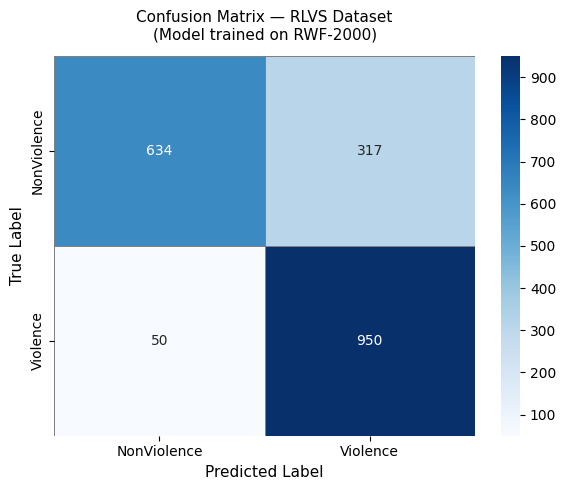

In [13]:
# ── CELL — Evaluate on full RLVS dataset ─────────────────────
BASE      = '/content/drive/MyDrive/violence-detection'
SAVE_PATH = f'{BASE}/results/rlvs_eval_progress.json'

# Delete old progress if exists
if os.path.exists(SAVE_PATH):
    os.remove(SAVE_PATH)
    print('Old progress deleted.')

done_paths = set()
all_preds, all_labels, failed = [], [], []
print('Starting fresh.')

remaining = all_samples
print(f'Total to evaluate: {len(remaining)} videos')

for i, (video_path, true_label) in enumerate(tqdm(remaining, desc='Evaluating')):
    try:
        skeleton = extract_skeleton(video_path)
        rgb_p    = get_rgb_probs(rgb_model, video_path)
        joint_p  = get_agcn_probs(joint_model, copy.deepcopy(skeleton))
        bone_p   = get_agcn_probs(bone_model,  copy.deepcopy(skeleton))
        fused    = W_RGB * rgb_p + W_JOINT * joint_p + W_BONE * bone_p
        pred     = int(np.argmax(fused))
        all_preds.append(pred)
        all_labels.append(true_label)
        done_paths.add(video_path)
    except Exception as e:
        failed.append([video_path, str(e)])

    # Save progress every 100 videos
    if (i + 1) % 100 == 0:
        with open(SAVE_PATH, 'w') as f:
            json.dump({'paths': list(done_paths), 'preds': all_preds,
                       'labels': all_labels, 'failed': failed}, f)
        print(f'  Saved at {len(all_preds)} videos.')

print(f'Done. Evaluated: {len(all_preds)}  Failed: {len(failed)}')

# ── Results ───────────────────────────────────────────────────
labels_arr = np.array(all_labels)
preds_arr  = np.array(all_preds)

acc = accuracy_score(labels_arr, preds_arr)
f1  = f1_score(labels_arr, preds_arr)

print('=' * 50)
print(f'Accuracy: {acc*100:.2f}%')
print(f'F1 Score: {f1:.4f}')
print('=' * 50)
print(classification_report(labels_arr, preds_arr,
      target_names=['NonViolence', 'Violence']))

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(labels_arr, preds_arr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NonViolence', 'Violence'],
            yticklabels=['NonViolence', 'Violence'],
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — RLVS Dataset\n(Model trained on RWF-2000)',
          fontsize=11, pad=12)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.savefig(f'{BASE}/results/confusion_matrix_rlvs.png', dpi=150, bbox_inches='tight')
plt.show()